# Notebook 2: Dataset Preparation + Face Embedding Database

**Master's Thesis: Thai Text-to-Segment System**

This notebook covers:
1. Loading and organizing face images
2. Creating face embeddings using InsightFace
3. Testing face identification
4. Saving the embedding database

---

## Setup and Imports

In [12]:
# Standard library imports
import os
import sys
import json
import pickle
from pathlib import Path
from collections import defaultdict

# Data processing
import numpy as np
import pandas as pd
from tqdm import tqdm

# Image processing
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

# Dimensionality reduction for visualization
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Similarity metrics
from scipy.spatial.distance import cosine, euclidean

# Set random seeds for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful!")

✅ All imports successful!


In [13]:
# Install InsightFace if not already installed
try:
    import insightface
    from insightface.app import FaceAnalysis
    print(f"✅ InsightFace version: {insightface.__version__}")
except ImportError:
    print("Installing InsightFace...")
    !pip install insightface onnxruntime -q
    import insightface
    from insightface.app import FaceAnalysis
    print("✅ InsightFace installed successfully!")

✅ InsightFace version: 0.7.3


## Configuration

In [14]:
# Configuration
CONFIG = {
    # Paths - Using actual dataset in /Dataset/
    'data_dir': Path('./Dataset'),
    'output_dir': Path('./output'),
    'embeddings_dir': Path('./output/embeddings'),
    'models_dir': Path('./models'),
    
    # Face detection settings
    'detection_threshold': 0.5,
    'recognition_threshold': 0.4,
    
    # Model settings
    'face_model': 'buffalo_l',  # Options: buffalo_l, buffalo_m, buffalo_s
    
    # IVE member information (mapped from folder names)
    'members': {
        'An_Yujin': 'Yujin',
        'Kim_Gaeul': 'Gaeul',
        'Naoi_Rei': 'Rei',
        'Jang_Wonyoung': 'Wonyoung',
        'Kim_Jiwon': 'Liz',
        'Lee_Hyunseo': 'Leeseo'
    },
    'member_colors': {
        'Yujin': '#FF6B6B',
        'Gaeul': '#4ECDC4',
        'Rei': '#45B7D1',
        'Wonyoung': '#96CEB4',
        'Liz': '#FFEAA7',
        'Leeseo': '#DDA0DD'
    }
}

# Create output directories
CONFIG['output_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['embeddings_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['models_dir'].mkdir(parents=True, exist_ok=True)

print("📁 Configuration loaded:")
print(f"   Data directory: {CONFIG['data_dir']}")
print(f"   Output directory: {CONFIG['output_dir']}")
print(f"   Members found: {len(CONFIG['members'])}")
for folder, name in CONFIG['members'].items():
    print(f"     - {folder} -> {name}")

📁 Configuration loaded:
   Data directory: Dataset
   Output directory: output
   Members found: 6
     - An_Yujin -> Yujin
     - Kim_Gaeul -> Gaeul
     - Naoi_Rei -> Rei
     - Jang_Wonyoung -> Wonyoung
     - Kim_Jiwon -> Liz
     - Lee_Hyunseo -> Leeseo


---

# Section 1: Load Face Images

Load and organize face images by IVE member.

## 1.1 Explore Dataset Structure

In [15]:
def explore_dataset_structure(base_dir):
    """
    Explore the dataset structure and count images per member.
    Dataset structure: /Dataset/{Member_Name}/{Member_Name}_{number}.jpg
    
    Args:
        base_dir: Path to the dataset directory
    
    Returns:
        dict: Statistics about the dataset
    """
    stats = {
        'total_images': 0,
        'members': {},
        'image_formats': defaultdict(int)
    }
    
    if not base_dir.exists():
        print(f"⚠️ Directory not found: {base_dir}")
        return stats
    
    # List all subdirectories (member folders)
    member_folders = [d for d in base_dir.iterdir() if d.is_dir()]
    print(f"\n📁 Found {len(member_folders)} member folders")
    
    for member_dir in member_folders:
        member_name = member_dir.name
        images = list(member_dir.glob('*'))
        images = [img for img in images if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']]
        stats['members'][member_name] = len(images)
        stats['total_images'] += len(images)
        
        for img in images:
            stats['image_formats'][img.suffix.lower()] += 1
    
    return stats

# Explore dataset
dataset_stats = explore_dataset_structure(CONFIG['data_dir'])

print("\n📊 Dataset Statistics:")
print(f"   Total images: {dataset_stats['total_images']}")
print("\n   Images per member:")
for member, count in sorted(dataset_stats['members'].items()):
    mapped_name = CONFIG['members'].get(member, member)
    print(f"      {member} ({mapped_name}): {count} images")
print("\n   Image formats:")
for fmt, count in dataset_stats['image_formats'].items():
    print(f"      {fmt}: {count}")


📁 Found 6 member folders

📊 Dataset Statistics:
   Total images: 180

   Images per member:
      An_Yujin (Yujin): 30 images
      Jang_Wonyoung (Wonyoung): 28 images
      Kim_Gaeul (Gaeul): 22 images
      Kim_Jiwon (Liz): 36 images
      Lee_Hyunseo (Leeseo): 39 images
      Naoi_Rei (Rei): 25 images

   Image formats:
      .jpg: 125
      .jpeg: 52
      .png: 3


## 1.2 Load Images Function

In [16]:
def load_member_images(base_dir, members=None, max_images_per_member=None):
    """
    Load images for specified members from dataset.
    
    Args:
        base_dir: Path to dataset directory
        members: List of member folder names (default: all from CONFIG['members'])
        max_images_per_member: Maximum images to load per member (None = all)
    
    Returns:
        dict: Dictionary mapping member names to list of (image_path, image_array) tuples
    """
    if members is None:
        members = list(CONFIG['members'].keys())
    
    member_images = {}
    
    for member in members:
        member_dir = base_dir / member
        if not member_dir.exists():
            print(f"⚠️ Directory not found for {member}: {member_dir}")
            continue
        
        # Get image files
        image_files = list(member_dir.glob('*'))
        image_files = [f for f in image_files if f.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']]
        
        if max_images_per_member:
            image_files = image_files[:max_images_per_member]
        
        # Load images
        images = []
        for img_path in tqdm(image_files, desc=f"Loading {member}", leave=False):
            try:
                # Load with OpenCV (BGR format)
                img = cv2.imread(str(img_path))
                if img is not None:
                    # Convert BGR to RGB
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    images.append((img_path, img_rgb))
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
        
        member_images[member] = images
        member_display = CONFIG['members'].get(member, member)
        print(f"✅ Loaded {len(images)} images for {member} ({member_display})")
    
    return member_images

# Load member images from actual dataset
print("\n📂 Loading member images from Dataset/...")
member_images = load_member_images(CONFIG['data_dir'], max_images_per_member=None)


📂 Loading member images from Dataset/...


✅ Loaded 30 images for An_Yujin (Yujin)


✅ Loaded 22 images for Kim_Gaeul (Gaeul)


✅ Loaded 25 images for Naoi_Rei (Rei)


✅ Loaded 28 images for Jang_Wonyoung (Wonyoung)


✅ Loaded 36 images for Kim_Jiwon (Liz)


✅ Loaded 39 images for Lee_Hyunseo (Leeseo)


## 1.3 Visualize Sample Images

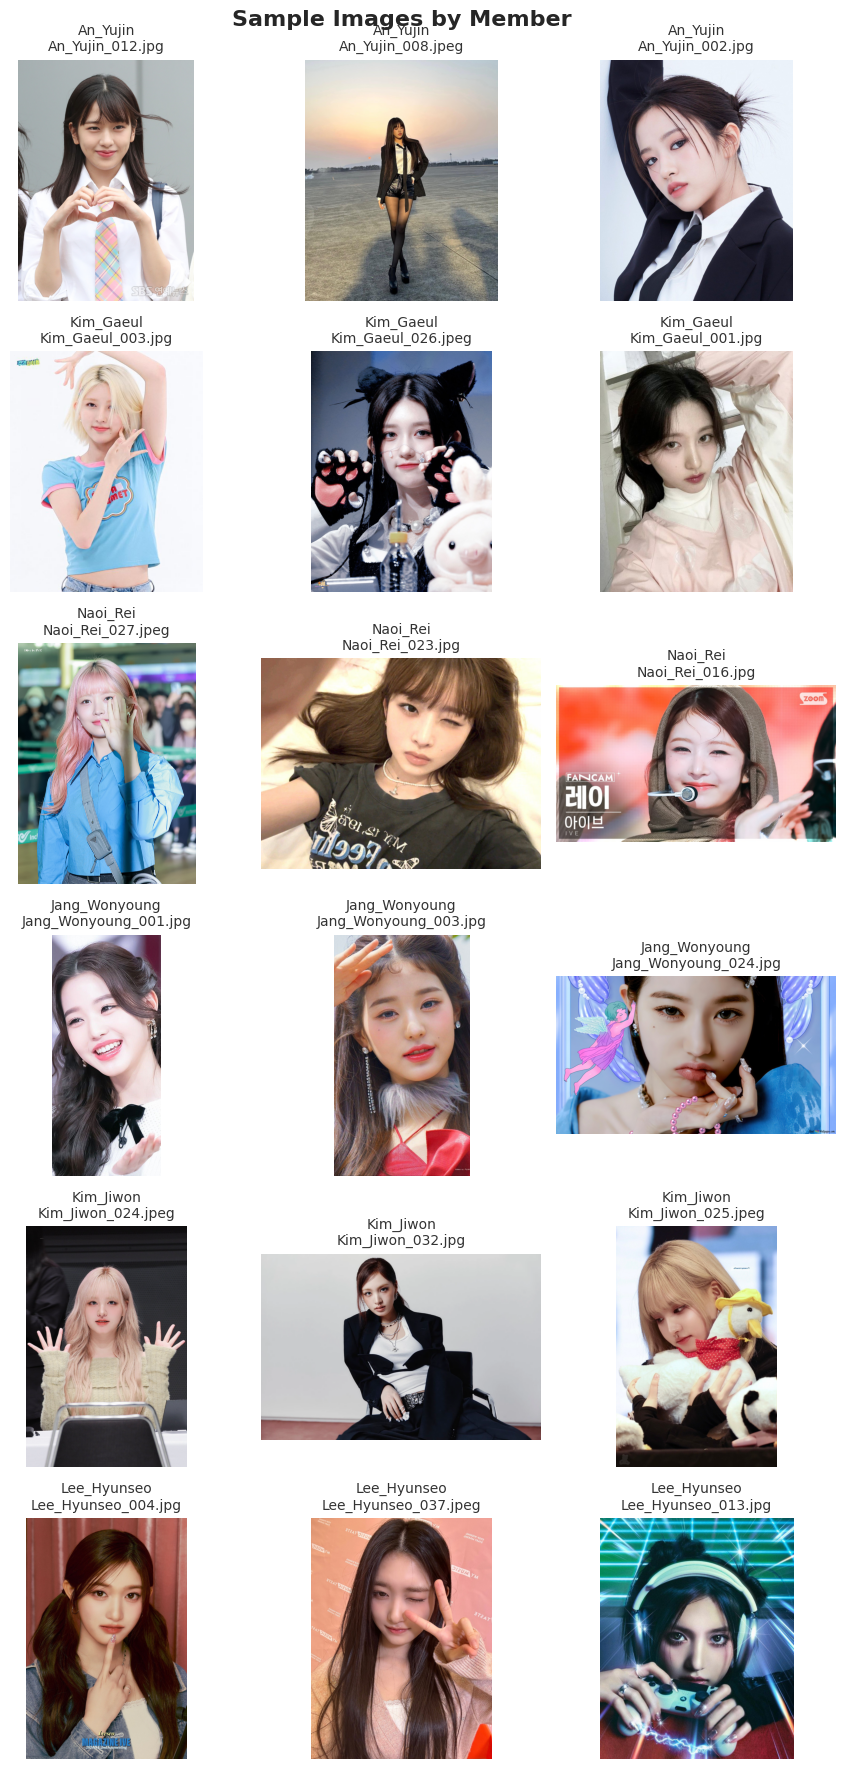


💾 Saved visualization to: output/01_sample_images.png


In [17]:
def visualize_member_samples(member_images, samples_per_member=3):
    """
    Visualize sample images from each member.
    
    Args:
        member_images: Dictionary of member -> list of (path, image) tuples
        samples_per_member: Number of samples to show per member
    """
    members = list(member_images.keys())
    n_members = len(members)
    
    fig, axes = plt.subplots(n_members, samples_per_member, 
                            figsize=(samples_per_member * 3, n_members * 3))
    
    if n_members == 1:
        axes = axes.reshape(1, -1)
    
    for i, member in enumerate(members):
        images = member_images[member]
        color = CONFIG['member_colors'].get(member, '#333333')
        
        for j in range(samples_per_member):
            ax = axes[i, j] if n_members > 1 else axes[j]
            
            if j < len(images):
                img_path, img = images[j]
                ax.imshow(img)
                ax.set_title(f"{member}\n{img_path.name}", color=color, fontsize=10)
            else:
                ax.text(0.5, 0.5, 'No Image', ha='center', va='center')
            
            ax.axis('off')
    
    plt.suptitle('Sample Images by Member', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / '01_sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n💾 Saved visualization to: {CONFIG['output_dir'] / '01_sample_images.png'}")

# Visualize samples
visualize_member_samples(member_images, samples_per_member=3)

---

# Section 2: Create Face Embeddings

Extract face embeddings using InsightFace and create an embedding database.

## 2.1 Initialize InsightFace Model

In [18]:
def initialize_face_analyzer(model_name='buffalo_l', det_thresh=0.5):
    """
    Initialize the InsightFace analyzer.
    
    Args:
        model_name: Model name ('buffalo_l', 'buffalo_m', 'buffalo_s')
        det_thresh: Detection threshold
    
    Returns:
        FaceAnalysis: Initialized face analyzer
    """
    print(f"🔄 Initializing InsightFace with model: {model_name}")
    
    # Initialize face analysis
    app = FaceAnalysis(name=model_name, root='../models')
    app.prepare(ctx_id=0, det_thresh=det_thresh)
    
    print(f"✅ Face analyzer initialized!")
    print(f"   Detection threshold: {det_thresh}")
    print(f"   Model: {model_name}")
    
    return app

# Initialize the face analyzer
face_app = initialize_face_analyzer(
    model_name=CONFIG['face_model'],
    det_thresh=CONFIG['detection_threshold']
)

🔄 Initializing InsightFace with model: buffalo_l
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: ../models/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionPr

## 2.2 Extract Face Embeddings

In [19]:
def extract_face_embedding(face_app, image, return_face_info=False):
    """
    Extract face embedding from an image.
    
    Args:
        face_app: Initialized FaceAnalysis object
        image: RGB image array
        return_face_info: Whether to return additional face information
    
    Returns:
        tuple: (embedding, face_info) or just embedding
    """
    # Detect faces
    faces = face_app.get(image)
    
    if len(faces) == 0:
        return (None, None) if return_face_info else None
    
    # Get the face with highest detection score
    face = max(faces, key=lambda f: f.det_score)
    
    # Get embedding (512-dimensional vector)
    embedding = face.embedding
    
    if return_face_info:
        face_info = {
            'bbox': face.bbox.astype(int),
            'det_score': float(face.det_score),
            'kps': face.kps,
            'embedding': embedding
        }
        return embedding, face_info
    
    return embedding

def extract_embeddings_for_dataset(face_app, member_images):
    """
    Extract embeddings for all images in the dataset.
    
    Args:
        face_app: Initialized FaceAnalysis object
        member_images: Dictionary of member -> list of (path, image) tuples
    
    Returns:
        dict: Embedding database with metadata
    """
    embedding_db = {
        'embeddings': [],
        'member_labels': [],
        'image_paths': [],
        'face_info': [],
        'failed_images': []
    }
    
    total_processed = 0
    total_failed = 0
    
    for member, images in member_images.items():
        print(f"\n🔄 Processing {member} ({len(images)} images)...")
        
        member_success = 0
        member_failed = 0
        
        for img_path, img in tqdm(images, desc=member, leave=False):
            embedding, face_info = extract_face_embedding(face_app, img, return_face_info=True)
            
            if embedding is not None:
                embedding_db['embeddings'].append(embedding)
                embedding_db['member_labels'].append(member)
                embedding_db['image_paths'].append(str(img_path))
                embedding_db['face_info'].append(face_info)
                member_success += 1
            else:
                embedding_db['failed_images'].append({
                    'path': str(img_path),
                    'member': member,
                    'reason': 'No face detected'
                })
                member_failed += 1
        
        print(f"   ✅ Success: {member_success}, ❌ Failed: {member_failed}")
        total_processed += member_success
        total_failed += member_failed
    
    # Convert to numpy arrays
    embedding_db['embeddings'] = np.array(embedding_db['embeddings'])
    embedding_db['member_labels'] = np.array(embedding_db['member_labels'])
    
    print(f"\n📊 Extraction Summary:")
    print(f"   Total processed: {total_processed}")
    print(f"   Total failed: {total_failed}")
    print(f"   Embedding dimension: {embedding_db['embeddings'].shape[1] if len(embedding_db['embeddings']) > 0 else 0}")
    
    return embedding_db

# Extract embeddings
print("🔍 Extracting face embeddings...")
embedding_db = extract_embeddings_for_dataset(face_app, member_images)

🔍 Extracting face embeddings...

🔄 Processing An_Yujin (30 images)...


   ✅ Success: 29, ❌ Failed: 1

🔄 Processing Kim_Gaeul (22 images)...


   ✅ Success: 22, ❌ Failed: 0

🔄 Processing Naoi_Rei (25 images)...


   ✅ Success: 25, ❌ Failed: 0

🔄 Processing Jang_Wonyoung (28 images)...


   ✅ Success: 26, ❌ Failed: 2

🔄 Processing Kim_Jiwon (36 images)...


   ✅ Success: 35, ❌ Failed: 1

🔄 Processing Lee_Hyunseo (39 images)...


   ✅ Success: 39, ❌ Failed: 0

📊 Extraction Summary:
   Total processed: 176
   Total failed: 4
   Embedding dimension: 512


## 2.3 Analyze Embedding Statistics

In [20]:
def analyze_embedding_statistics(embedding_db):
    """
    Analyze and display embedding statistics.
    
    Args:
        embedding_db: Embedding database dictionary
    """
    embeddings = embedding_db['embeddings']
    labels = embedding_db['member_labels']
    
    print("\n📈 Embedding Statistics:")
    print(f"   Total embeddings: {len(embeddings)}")
    print(f"   Embedding dimension: {embeddings.shape[1]}")
    print(f"\n   Embedding value statistics:")
    print(f"      Mean: {np.mean(embeddings):.6f}")
    print(f"      Std: {np.std(embeddings):.6f}")
    print(f"      Min: {np.min(embeddings):.6f}")
    print(f"      Max: {np.max(embeddings):.6f}")
    
    # Per-member statistics
    print(f"\n   Embeddings per member:")
    unique_members = np.unique(labels)
    for member in unique_members:
        count = np.sum(labels == member)
        member_embeddings = embeddings[labels == member]
        print(f"      {member}: {count} embeddings")
        print(f"         Mean norm: {np.mean(np.linalg.norm(member_embeddings, axis=1)):.4f}")
    
    # Embedding norms
    norms = np.linalg.norm(embeddings, axis=1)
    print(f"\n   Embedding norms:")
    print(f"      Mean: {np.mean(norms):.4f}")
    print(f"      Std: {np.std(norms):.4f}")
    
    return {
        'mean': np.mean(embeddings),
        'std': np.std(embeddings),
        'norms': norms
    }

# Analyze statistics
stats = analyze_embedding_statistics(embedding_db)


📈 Embedding Statistics:
   Total embeddings: 176
   Embedding dimension: 512

   Embedding value statistics:
      Mean: 0.012120
      Std: 0.929856
      Min: -4.153157
      Max: 3.870719

   Embeddings per member:
      An_Yujin: 29 embeddings
         Mean norm: 20.8622
      Jang_Wonyoung: 26 embeddings
         Mean norm: 20.8895
      Kim_Gaeul: 22 embeddings
         Mean norm: 20.9833
      Kim_Jiwon: 35 embeddings
         Mean norm: 21.1996
      Lee_Hyunseo: 39 embeddings
         Mean norm: 21.8832
      Naoi_Rei: 25 embeddings
         Mean norm: 19.6541

   Embedding norms:
      Mean: 21.0031
      Std: 1.2795


## 2.4 Visualize Embeddings

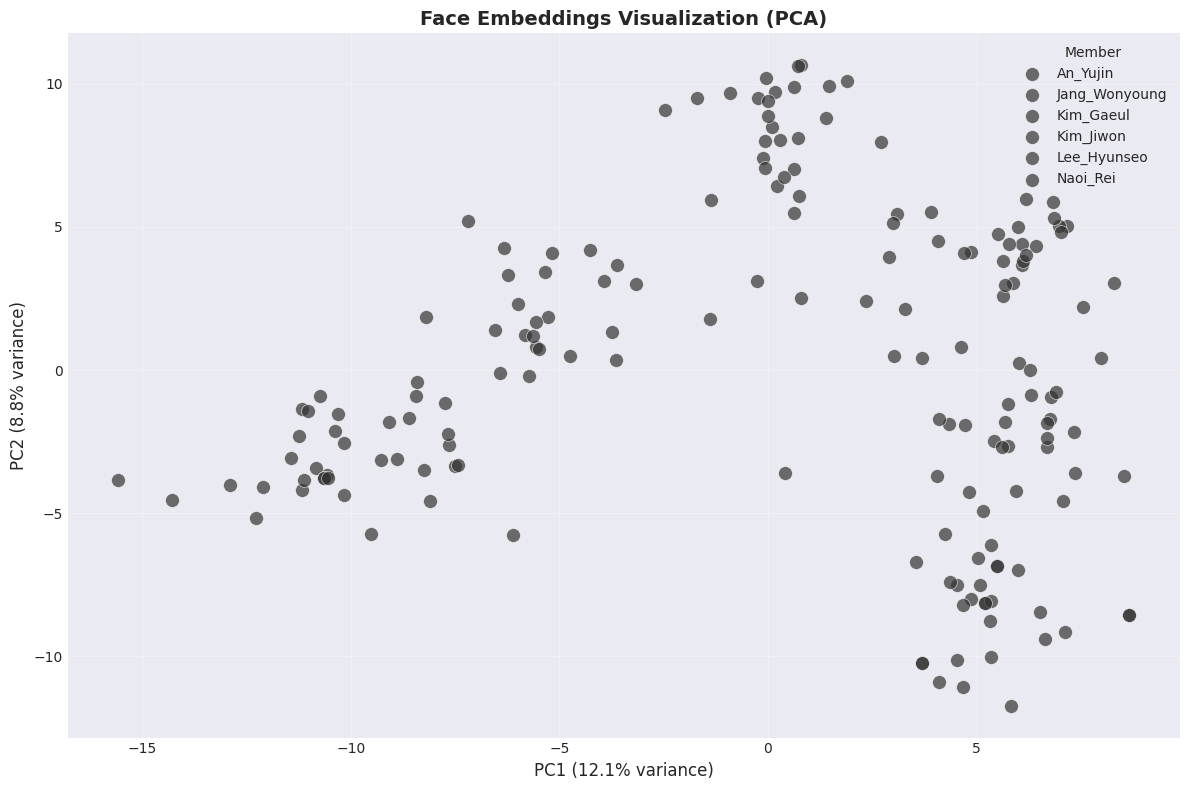


💾 Saved PCA visualization to: output/02_embeddings_pca.png
   Explained variance: PC1=12.05%, PC2=8.83%


In [21]:
def visualize_embeddings_pca(embedding_db):
    """
    Visualize embeddings using PCA.
    
    Args:
        embedding_db: Embedding database dictionary
    """
    embeddings = embedding_db['embeddings']
    labels = embedding_db['member_labels']
    
    # Apply PCA
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    unique_members = np.unique(labels)
    for member in unique_members:
        mask = labels == member
        color = CONFIG['member_colors'].get(member, '#333333')
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=color,
            label=member,
            alpha=0.7,
            s=100,
            edgecolors='white',
            linewidth=0.5
        )
    
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    ax.set_title('Face Embeddings Visualization (PCA)', fontsize=14, fontweight='bold')
    ax.legend(title='Member', loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / '02_embeddings_pca.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Saved PCA visualization to: {CONFIG['output_dir'] / '02_embeddings_pca.png'}")
    print(f"   Explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")
    
    return pca

# Visualize with PCA
pca_model = visualize_embeddings_pca(embedding_db)

🔄 Running t-SNE with perplexity=5...


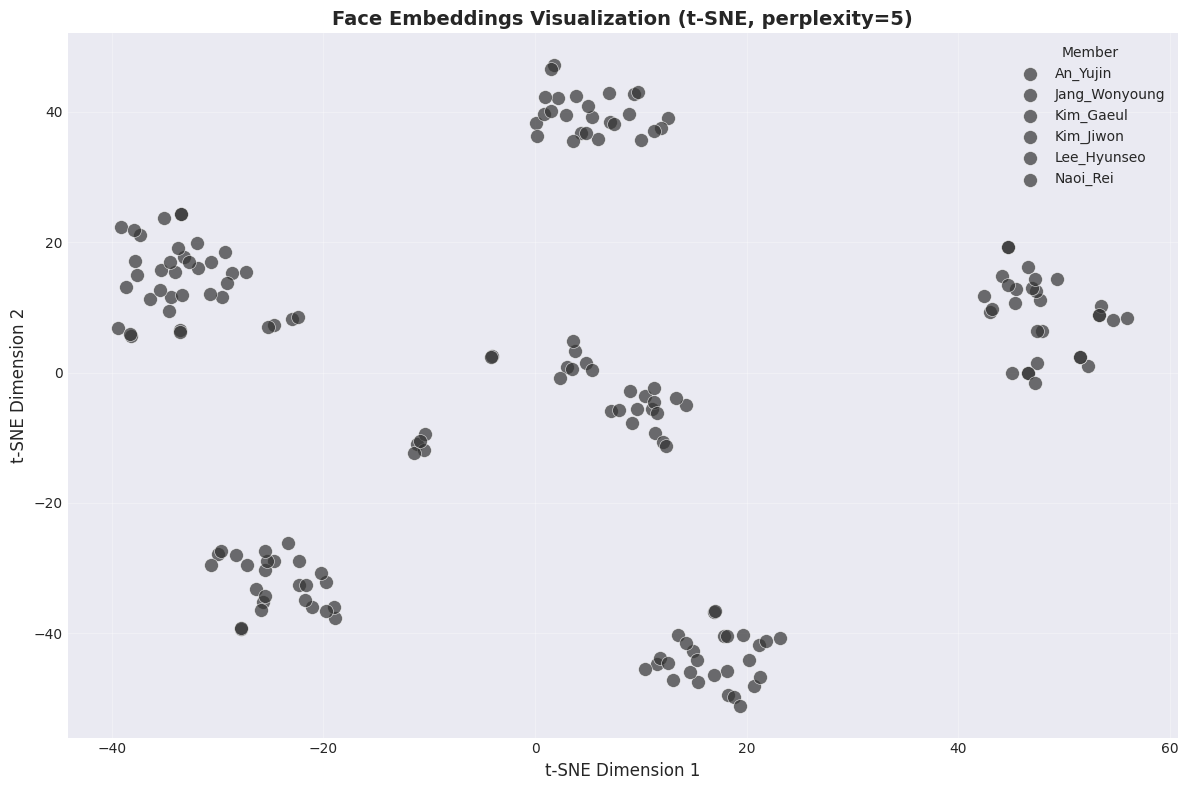


💾 Saved t-SNE visualization to: output/03_embeddings_tsne.png


In [22]:
def visualize_embeddings_tsne(embedding_db, perplexity=5):
    """
    Visualize embeddings using t-SNE.
    
    Args:
        embedding_db: Embedding database dictionary
        perplexity: t-SNE perplexity parameter
    """
    embeddings = embedding_db['embeddings']
    labels = embedding_db['member_labels']
    
    print(f"🔄 Running t-SNE with perplexity={perplexity}...")
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, max_iter=1000)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    unique_members = np.unique(labels)
    for member in unique_members:
        mask = labels == member
        color = CONFIG['member_colors'].get(member, '#333333')
        ax.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=color,
            label=member,
            alpha=0.7,
            s=100,
            edgecolors='white',
            linewidth=0.5
        )
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.set_title(f'Face Embeddings Visualization (t-SNE, perplexity={perplexity})', 
                fontsize=14, fontweight='bold')
    ax.legend(title='Member', loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / '03_embeddings_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Saved t-SNE visualization to: {CONFIG['output_dir'] / '03_embeddings_tsne.png'}")
    
    return tsne

# Visualize with t-SNE (use small perplexity for small datasets)
tsne_model = visualize_embeddings_tsne(embedding_db, perplexity=min(5, len(embedding_db['embeddings'])-1))

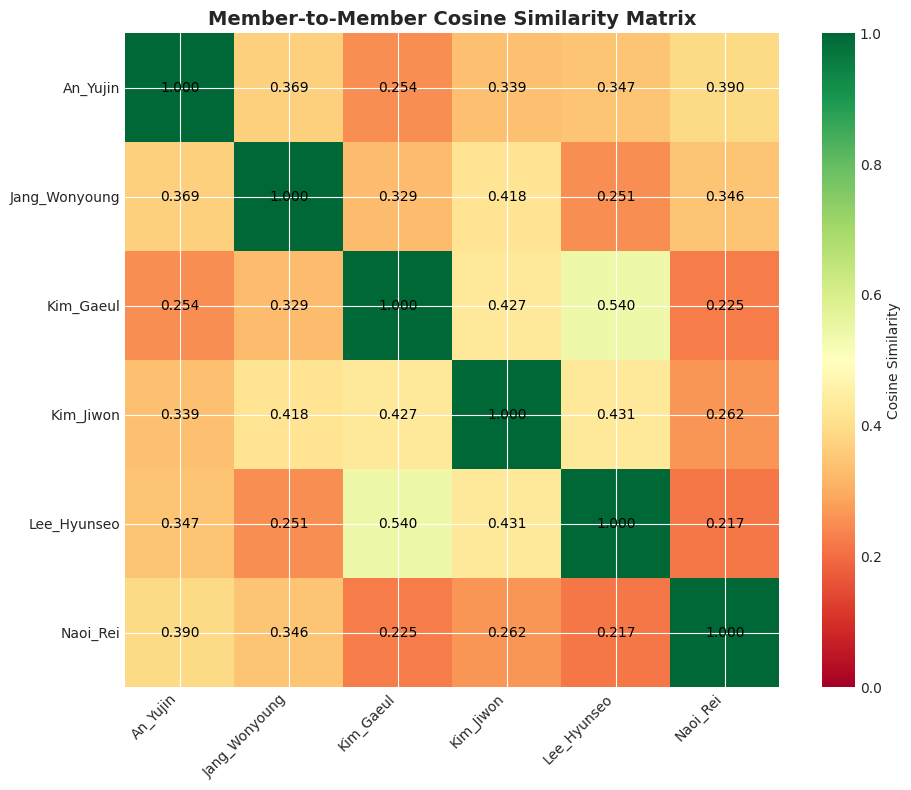


💾 Saved similarity matrix to: output/04_similarity_matrix.png


In [23]:
def plot_embedding_similarity_matrix(embedding_db):
    """
    Plot similarity matrix between member average embeddings.
    
    Args:
        embedding_db: Embedding database dictionary
    """
    embeddings = embedding_db['embeddings']
    labels = embedding_db['member_labels']
    
    # Compute average embedding per member
    unique_members = np.unique(labels)
    member_embeddings = {}
    
    for member in unique_members:
        mask = labels == member
        member_embeddings[member] = np.mean(embeddings[mask], axis=0)
    
    # Compute similarity matrix
    n_members = len(unique_members)
    similarity_matrix = np.zeros((n_members, n_members))
    
    for i, member1 in enumerate(unique_members):
        for j, member2 in enumerate(unique_members):
            emb1 = member_embeddings[member1]
            emb2 = member_embeddings[member2]
            # Cosine similarity
            similarity = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
            similarity_matrix[i, j] = similarity
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    
    im = ax.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
    
    # Set ticks
    ax.set_xticks(np.arange(n_members))
    ax.set_yticks(np.arange(n_members))
    ax.set_xticklabels(unique_members, rotation=45, ha='right')
    ax.set_yticklabels(unique_members)
    
    # Add text annotations
    for i in range(n_members):
        for j in range(n_members):
            text = ax.text(j, i, f'{similarity_matrix[i, j]:.3f}',
                          ha='center', va='center', color='black', fontsize=10)
    
    ax.set_title('Member-to-Member Cosine Similarity Matrix', fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Cosine Similarity')
    
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / '04_similarity_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Saved similarity matrix to: {CONFIG['output_dir'] / '04_similarity_matrix.png'}")
    
    return similarity_matrix

# Plot similarity matrix
similarity_matrix = plot_embedding_similarity_matrix(embedding_db)

---

# Section 3: Test Face Identification

Test face identification on sample images and visualize similarity scores.

## 3.1 Face Identification Functions

In [24]:
def identify_face(query_embedding, embedding_db, metric='cosine', top_k=3):
    """
    Identify a face by comparing with the embedding database.
    
    Args:
        query_embedding: Query face embedding
        embedding_db: Embedding database dictionary
        metric: Similarity metric ('cosine', 'euclidean')
        top_k: Number of top matches to return
    
    Returns:
        list: Top-k matches with member and score
    """
    embeddings = embedding_db['embeddings']
    labels = embedding_db['member_labels']
    
    # Normalize embeddings for cosine similarity
    query_norm = query_embedding / np.linalg.norm(query_embedding)
    db_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    
    if metric == 'cosine':
        # Cosine similarity (higher is better)
        similarities = np.dot(db_norm, query_norm)
        # Get top-k indices
        top_indices = np.argsort(similarities)[::-1][:top_k]
        results = [(labels[idx], float(similarities[idx])) for idx in top_indices]
    else:
        # Euclidean distance (lower is better)
        distances = np.linalg.norm(embeddings - query_embedding, axis=1)
        top_indices = np.argsort(distances)[:top_k]
        results = [(labels[idx], float(1 / (1 + distances[idx]))) for idx in top_indices]
    
    return results

def get_member_average_embedding(embedding_db, member):
    """
    Get the average embedding for a specific member.
    
    Args:
        embedding_db: Embedding database dictionary
        member: Member name
    
    Returns:
        np.array: Average embedding for the member
    """
    mask = embedding_db['member_labels'] == member
    return np.mean(embedding_db['embeddings'][mask], axis=0)

def identify_face_by_member_average(query_embedding, embedding_db):
    """
    Identify face by comparing with member average embeddings.
    
    Args:
        query_embedding: Query face embedding
        embedding_db: Embedding database dictionary
    
    Returns:
        list: All members ranked by similarity
    """
    unique_members = np.unique(embedding_db['member_labels'])
    results = []
    
    query_norm = query_embedding / np.linalg.norm(query_embedding)
    
    for member in unique_members:
        member_emb = get_member_average_embedding(embedding_db, member)
        member_norm = member_emb / np.linalg.norm(member_emb)
        similarity = np.dot(query_norm, member_norm)
        results.append((member, float(similarity)))
    
    # Sort by similarity (descending)
    results.sort(key=lambda x: x[1], reverse=True)
    
    return results

print("✅ Face identification functions defined!")

✅ Face identification functions defined!


## 3.2 Test on Sample Images

In [25]:
def test_face_identification(face_app, embedding_db, member_images, num_tests=3):
    """
    Test face identification on random sample images.
    
    Args:
        face_app: FaceAnalysis object
        embedding_db: Embedding database
        member_images: Dictionary of member images
        num_tests: Number of test samples
    """
    # Collect all images
    all_images = []
    for member, images in member_images.items():
        for img_path, img in images:
            all_images.append((member, img_path, img))
    
    # Randomly select test images
    test_indices = np.random.choice(len(all_images), min(num_tests, len(all_images)), replace=False)
    
    results = []
    
    for idx in test_indices:
        true_member, img_path, img = all_images[idx]
        
        # Extract embedding
        embedding, face_info = extract_face_embedding(face_app, img, return_face_info=True)
        
        if embedding is not None:
            # Identify
            matches = identify_face_by_member_average(embedding, embedding_db)
            results.append({
                'true_member': true_member,
                'img_path': img_path,
                'img': img,
                'face_info': face_info,
                'matches': matches
            })
    
    return results

# Run tests
print("🧪 Testing face identification...")
test_results = test_face_identification(face_app, embedding_db, member_images, num_tests=4)

🧪 Testing face identification...


## 3.3 Visualize Test Results

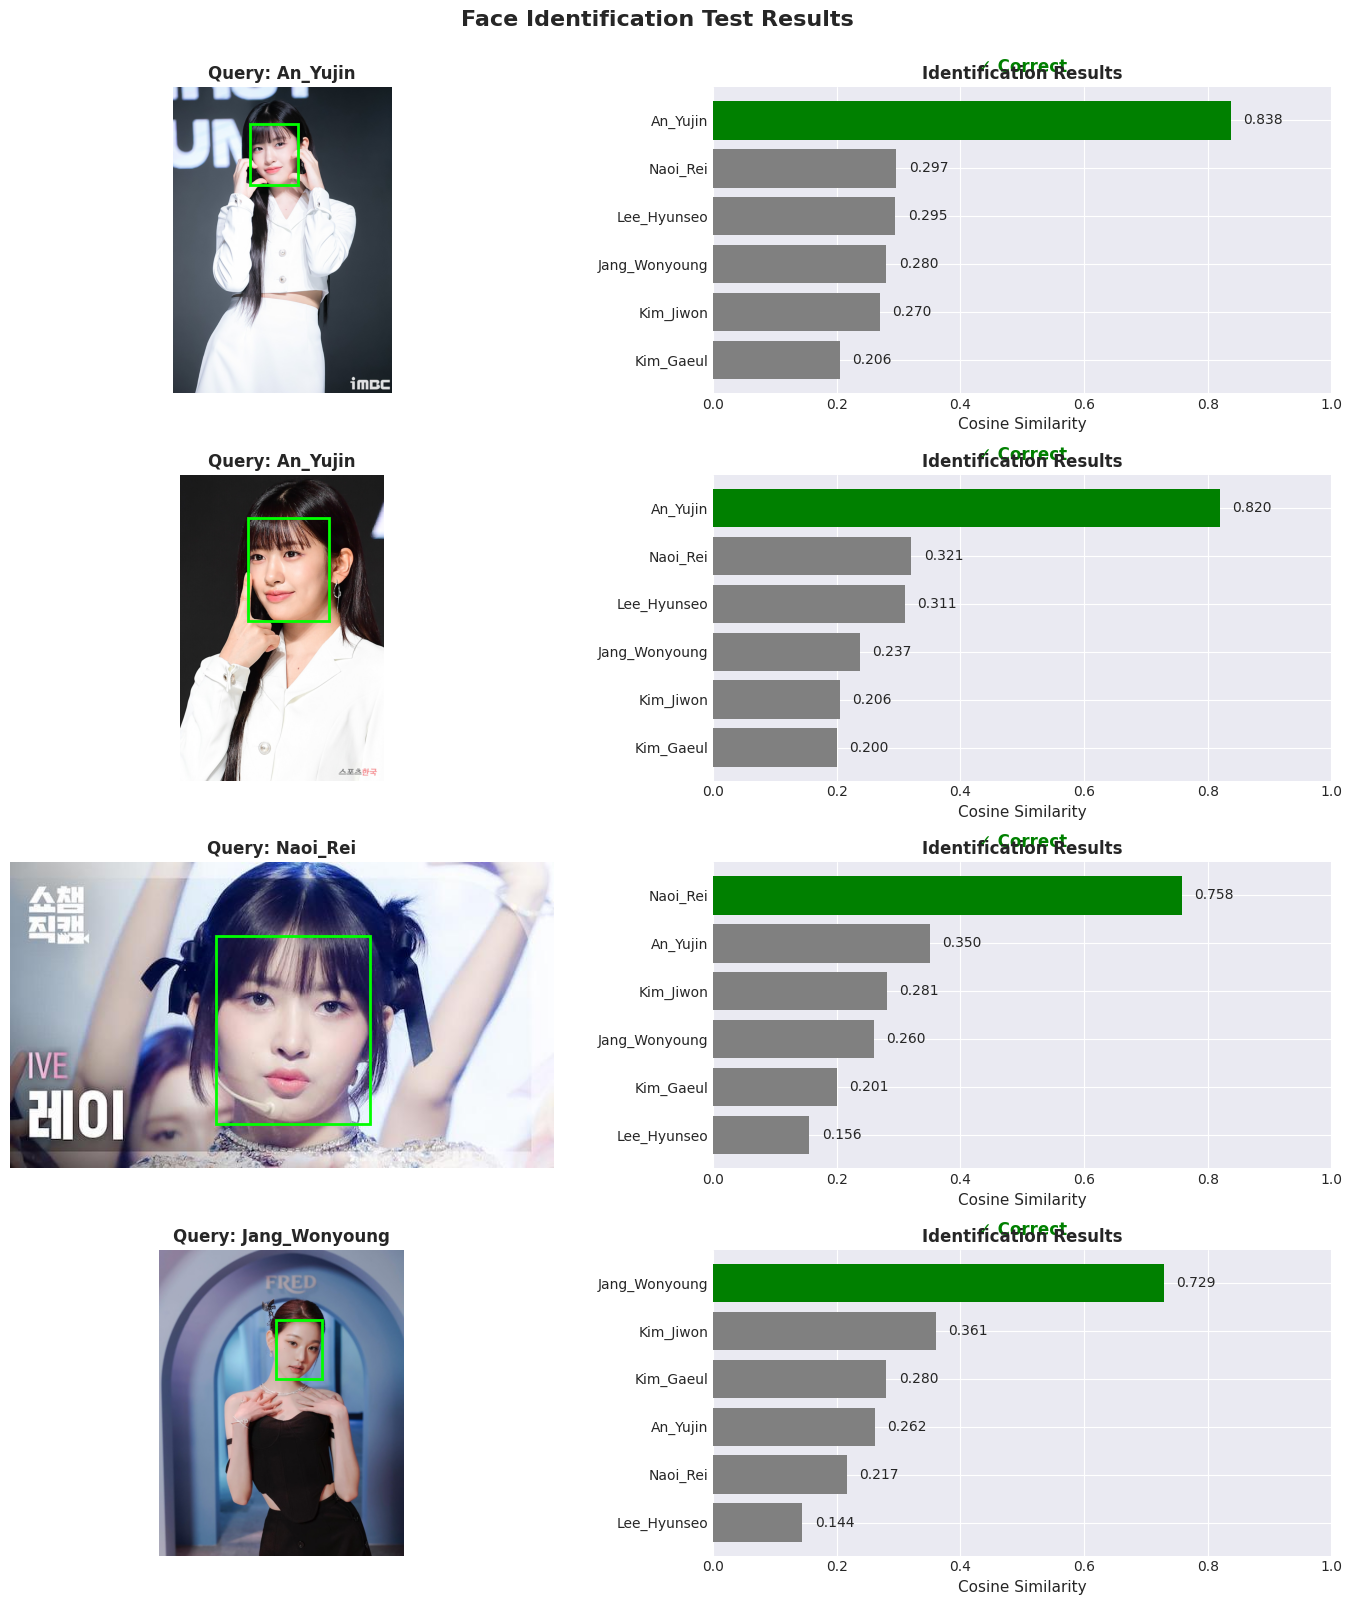


💾 Saved identification results to: output/05_identification_results.png


In [26]:
def visualize_identification_results(test_results):
    """
    Visualize face identification test results.
    
    Args:
        test_results: List of test result dictionaries
    """
    n_results = len(test_results)
    
    fig, axes = plt.subplots(n_results, 2, figsize=(14, 4 * n_results))
    
    if n_results == 1:
        axes = axes.reshape(1, -1)
    
    for i, result in enumerate(test_results):
        true_member = result['true_member']
        img = result['img']
        matches = result['matches']
        face_info = result['face_info']
        
        # Left: Image with face box
        ax_img = axes[i, 0]
        ax_img.imshow(img)
        
        # Draw face bounding box
        bbox = face_info['bbox']
        rect = Rectangle(
            (bbox[0], bbox[1]), bbox[2] - bbox[0], bbox[3] - bbox[1],
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax_img.add_patch(rect)
        ax_img.set_title(f'Query: {true_member}', fontsize=12, fontweight='bold')
        ax_img.axis('off')
        
        # Right: Similarity scores
        ax_scores = axes[i, 1]
        
        members = [m for m, _ in matches]
        scores = [s for _, s in matches]
        colors = ['green' if m == true_member else 'gray' for m in members]
        
        bars = ax_scores.barh(members[::-1], scores[::-1], color=colors[::-1])
        ax_scores.set_xlim(0, 1)
        ax_scores.set_xlabel('Cosine Similarity', fontsize=11)
        ax_scores.set_title('Identification Results', fontsize=12, fontweight='bold')
        
        # Add score labels
        for bar, score in zip(bars, scores[::-1]):
            ax_scores.text(score + 0.02, bar.get_y() + bar.get_height()/2, 
                        f'{score:.3f}', va='center', fontsize=10)
        
        # Highlight top match
        top_member = matches[0][0]
        if top_member == true_member:
            ax_scores.text(0.5, 1.05, '✓ Correct', transform=ax_scores.transAxes,
                         ha='center', fontsize=12, color='green', fontweight='bold')
        else:
            ax_scores.text(0.5, 1.05, f'✗ Predicted: {top_member}', transform=ax_scores.transAxes,
                         ha='center', fontsize=12, color='red', fontweight='bold')
    
    plt.suptitle('Face Identification Test Results', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(CONFIG['output_dir'] / '05_identification_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Saved identification results to: {CONFIG['output_dir'] / '05_identification_results.png'}")

# Visualize results
visualize_identification_results(test_results)

## 3.4 Calculate Identification Accuracy

In [27]:
def evaluate_identification_accuracy(face_app, embedding_db, member_images):
    """
    Evaluate face identification accuracy on all images.
    
    Args:
        face_app: FaceAnalysis object
        embedding_db: Embedding database
        member_images: Dictionary of member images
    
    Returns:
        dict: Evaluation metrics
    """
    correct = 0
    total = 0
    per_member_correct = defaultdict(int)
    per_member_total = defaultdict(int)
    
    print("\n📊 Evaluating identification accuracy...")
    
    for member, images in member_images.items():
        for img_path, img in tqdm(images, desc=f'Evaluating {member}', leave=False):
            # Extract embedding
            embedding = extract_face_embedding(face_app, img)
            
            if embedding is not None:
                # Identify
                matches = identify_face_by_member_average(embedding, embedding_db)
                predicted = matches[0][0]
                
                per_member_total[member] += 1
                total += 1
                
                if predicted == member:
                    correct += 1
                    per_member_correct[member] += 1
    
    accuracy = correct / total if total > 0 else 0
    
    print(f"\n📈 Overall Accuracy: {accuracy:.2%} ({correct}/{total})")
    print(f"\n📊 Per-Member Accuracy:")
    for member in CONFIG['members']:
        member_acc = per_member_correct[member] / per_member_total[member] if per_member_total[member] > 0 else 0
        print(f"   {member}: {member_acc:.2%} ({per_member_correct[member]}/{per_member_total[member]})")
    
    return {
        'accuracy': accuracy,
        'correct': correct,
        'total': total,
        'per_member_correct': dict(per_member_correct),
        'per_member_total': dict(per_member_total)
    }

# Evaluate accuracy
accuracy_results = evaluate_identification_accuracy(face_app, embedding_db, member_images)


📊 Evaluating identification accuracy...



📈 Overall Accuracy: 96.59% (170/176)

📊 Per-Member Accuracy:
   An_Yujin: 100.00% (29/29)
   Kim_Gaeul: 95.45% (21/22)
   Naoi_Rei: 100.00% (25/25)
   Jang_Wonyoung: 96.15% (25/26)
   Kim_Jiwon: 88.57% (31/35)
   Lee_Hyunseo: 100.00% (39/39)


---

# Section 4: Save Database

Save embeddings to disk and create metadata.

## 4.1 Save Embedding Database

In [28]:
def save_embedding_database(embedding_db, output_dir):
    """
    Save the embedding database to disk.
    
    Args:
        embedding_db: Embedding database dictionary
        output_dir: Output directory path
    
    Returns:
        dict: Paths to saved files
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    saved_paths = {}
    
    # Save embeddings as numpy array
    embeddings_path = output_dir / 'face_embeddings.npy'
    np.save(embeddings_path, embedding_db['embeddings'])
    saved_paths['embeddings'] = str(embeddings_path)
    print(f"✅ Saved embeddings: {embeddings_path}")
    
    # Save labels
    labels_path = output_dir / 'member_labels.npy'
    np.save(labels_path, embedding_db['member_labels'])
    saved_paths['labels'] = str(labels_path)
    print(f"✅ Saved labels: {labels_path}")
    
    # Save metadata as JSON
    metadata = {
        'num_embeddings': len(embedding_db['embeddings']),
        'embedding_dim': embedding_db['embeddings'].shape[1],
        'members': list(np.unique(embedding_db['member_labels'])),
        'image_paths': embedding_db['image_paths'],
        'failed_images': embedding_db['failed_images']
    }
    
    metadata_path = output_dir / 'metadata.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    saved_paths['metadata'] = str(metadata_path)
    print(f"✅ Saved metadata: {metadata_path}")
    
    # Save face info (without embeddings to avoid duplication)
    face_info_clean = []
    for info in embedding_db['face_info']:
        face_info_clean.append({
            'bbox': info['bbox'].tolist(),
            'det_score': info['det_score'],
            'kps': info['kps'].tolist() if hasattr(info['kps'], 'tolist') else info['kps']
        })
    
    face_info_path = output_dir / 'face_info.json'
    with open(face_info_path, 'w') as f:
        json.dump(face_info_clean, f, indent=2)
    saved_paths['face_info'] = str(face_info_path)
    print(f"✅ Saved face info: {face_info_path}")
    
    # Save complete database as pickle
    pickle_path = output_dir / 'embedding_database.pkl'
    with open(pickle_path, 'wb') as f:
        pickle.dump(embedding_db, f)
    saved_paths['pickle'] = str(pickle_path)
    print(f"✅ Saved pickle database: {pickle_path}")
    
    return saved_paths

# Save database
print("💾 Saving embedding database...")
saved_paths = save_embedding_database(embedding_db, CONFIG['embeddings_dir'])

💾 Saving embedding database...
✅ Saved embeddings: output/embeddings/face_embeddings.npy
✅ Saved labels: output/embeddings/member_labels.npy
✅ Saved metadata: output/embeddings/metadata.json
✅ Saved face info: output/embeddings/face_info.json
✅ Saved pickle database: output/embeddings/embedding_database.pkl


## 4.2 Create Database Summary

In [29]:
def create_database_summary(embedding_db, accuracy_results, saved_paths):
    """
    Create a summary of the embedding database.
    
    Args:
        embedding_db: Embedding database
        accuracy_results: Accuracy evaluation results
        saved_paths: Paths to saved files
    """
    summary = {
        'database_info': {
            'num_embeddings': len(embedding_db['embeddings']),
            'embedding_dimension': int(embedding_db['embeddings'].shape[1]),
            'members': list(np.unique(embedding_db['member_labels'])),
            'num_failed': len(embedding_db['failed_images'])
        },
        'accuracy': {
            'overall': accuracy_results['accuracy'],
            'correct': accuracy_results['correct'],
            'total': accuracy_results['total']
        },
        'saved_files': saved_paths
    }
    
    # Save summary
    summary_path = CONFIG['embeddings_dir'] / 'database_summary.json'
    with open(summary_path, 'w') as f:
        json.dump(summary, f, indent=2)
    
    print("\n📋 Database Summary:")
    print(f"   Total embeddings: {summary['database_info']['num_embeddings']}")
    print(f"   Embedding dimension: {summary['database_info']['embedding_dimension']}")
    print(f"   Members: {', '.join(summary['database_info']['members'])}")
    print(f"   Failed extractions: {summary['database_info']['num_failed']}")
    print(f"   Identification accuracy: {summary['accuracy']['overall']:.2%}")
    print(f"\n💾 Summary saved to: {summary_path}")
    
    return summary

# Create summary
summary = create_database_summary(embedding_db, accuracy_results, saved_paths)


📋 Database Summary:
   Total embeddings: 176
   Embedding dimension: 512
   Members: An_Yujin, Jang_Wonyoung, Kim_Gaeul, Kim_Jiwon, Lee_Hyunseo, Naoi_Rei
   Failed extractions: 4
   Identification accuracy: 96.59%

💾 Summary saved to: output/embeddings/database_summary.json


## 4.3 Verify Saved Database

In [30]:
def verify_saved_database(embeddings_dir):
    """
    Verify that the database was saved correctly.
    
    Args:
        embeddings_dir: Path to embeddings directory
    """
    embeddings_dir = Path(embeddings_dir)
    
    print("\n🔍 Verifying saved database...")
    
    # Load embeddings
    embeddings = np.load(embeddings_dir / 'face_embeddings.npy')
    print(f"✅ Embeddings loaded: {embeddings.shape}")
    
    # Load labels
    labels = np.load(embeddings_dir / 'member_labels.npy')
    print(f"✅ Labels loaded: {labels.shape}")
    
    # Load metadata
    with open(embeddings_dir / 'metadata.json', 'r') as f:
        metadata = json.load(f)
    print(f"✅ Metadata loaded: {len(metadata)} keys")
    
    # Load pickle
    with open(embeddings_dir / 'embedding_database.pkl', 'rb') as f:
        db = pickle.load(f)
    print(f"✅ Pickle loaded: {len(db)} keys")
    
    # Verify consistency
    assert len(embeddings) == len(labels), "Mismatch between embeddings and labels!"
    assert len(embeddings) == metadata['num_embeddings'], "Mismatch with metadata!"
    
    print("\n✅ All verifications passed!")
    
    return True

# Verify
verify_saved_database(CONFIG['embeddings_dir'])


🔍 Verifying saved database...
✅ Embeddings loaded: (176, 512)
✅ Labels loaded: (176,)
✅ Metadata loaded: 5 keys
✅ Pickle loaded: 5 keys

✅ All verifications passed!


True

---

# Section 5: SAM 3 Segmentation Setup

Setup SAM 3 from Hugging Face for segmentation tasks.

In [31]:
# Load SAM 3 from Hugging Face
# โหลด SAM 3 จาก Hugging Face
from transformers import Sam3Processor, Sam3Model
import torch

print("Loading SAM 3 from Hugging Face...")
print("="*50)

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load processor and model
HF_TOKEN = "YOUR_HF_TOKEN_HERE"
sam3_processor = Sam3Processor.from_pretrained("facebook/sam3", token=HF_TOKEN)
sam3_model = Sam3Model.from_pretrained("facebook/sam3", token=HF_TOKEN).to(device)

print("\n✅ SAM 3 loaded successfully!")
print(f"   Model: facebook/sam3")
print(f"   Device: {device}")

Loading SAM 3 from Hugging Face...
Device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]


✅ SAM 3 loaded successfully!
   Model: facebook/sam3
   Device: cuda


## 5.1 Test SAM 3 Segmentation on Sample Image

In [32]:
# Test SAM 3 on a sample image from dataset
from PIL import Image

def test_sam3_segmentation(image_path, text_prompt="person"):
    """
    Test SAM 3 segmentation on an image.
    
    Args:
        image_path: Path to image
        text_prompt: Text prompt for segmentation
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Process with SAM 3
    inputs = sam3_processor(images=image, text=text_prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = sam3_model(**inputs)
    
    # Post-process
    results = sam3_processor.post_process_instance_segmentation(
        outputs,
        threshold=0.5,
        mask_threshold=0.5,
        target_sizes=inputs.get("original_sizes").tolist()
    )[0]
    
    return image, results

# Test on first image from first member
first_member = list(member_images.keys())[0]
if member_images[first_member]:
    sample_path, sample_img = member_images[first_member][0]
    print(f"Testing SAM 3 on: {sample_path.name}")
    
    image, results = test_sam3_segmentation(sample_path, "person")
    print(f"\n✅ Detected {len(results.get('masks', []))} objects")
else:
    print("⚠️ No images available for testing")

Testing SAM 3 on: An_Yujin_012.jpg

✅ Detected 3 objects


## 5.2 Visualize SAM 3 Results

Saved to: output/06_sam3_segmentation.png


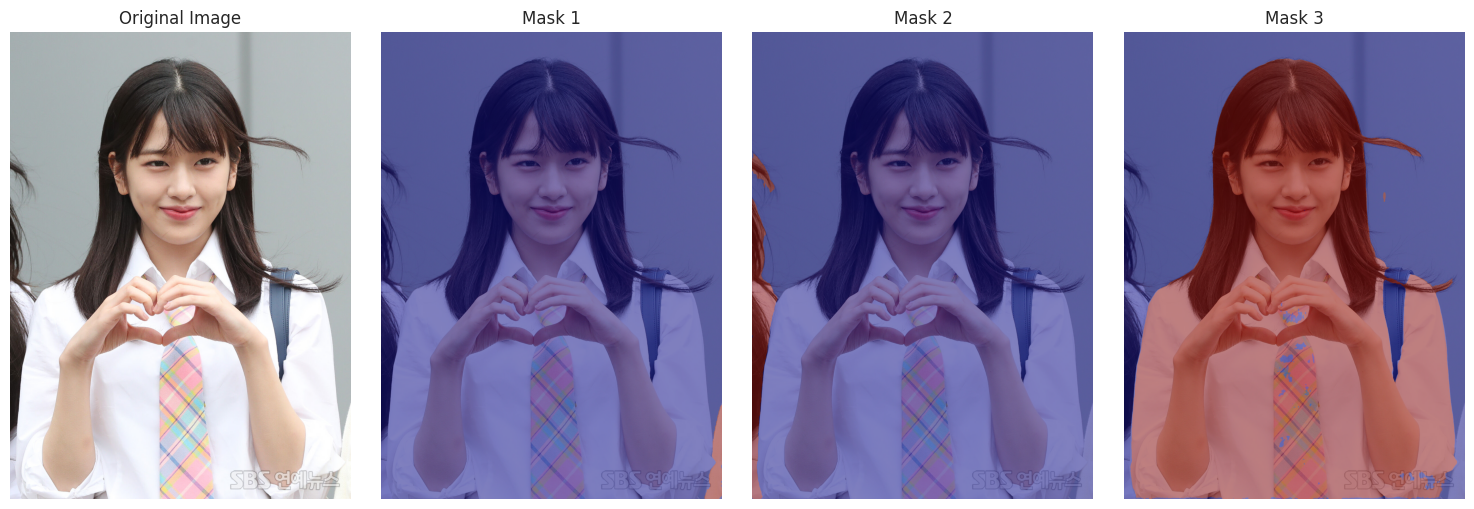

In [33]:
# Visualize SAM 3 segmentation results
def visualize_sam3_results(image, results, save_path=None):
    """
    Visualize SAM 3 segmentation results.
    """
    masks = results.get("masks", [])
    boxes = results.get("boxes", [])
    
    fig, axes = plt.subplots(1, min(len(masks) + 1, 4), figsize=(15, 5))
    if len(masks) == 0:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Show masks
    for i, (mask, box) in enumerate(zip(masks[:3], boxes[:3])):
        if i + 1 < len(axes):
            axes[i + 1].imshow(image)
            mask_np = mask.cpu().numpy() if torch.is_tensor(mask) else mask
            axes[i + 1].imshow(mask_np, alpha=0.5, cmap="jet")
            axes[i + 1].set_title(f"Mask {i+1}")
            axes[i + 1].axis("off")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Saved to: {save_path}")
    plt.show()

# Visualize results
if 'results' in dir():
    visualize_sam3_results(
        image, 
        results, 
        save_path=CONFIG['output_dir'] / '06_sam3_segmentation.png'
    )

# Print final summary
print("\n" + "="*60)
print("📊 NOTEBOOK 2 COMPLETE: Dataset Preparation + Face Embedding DB + SAM 3")
print("="*60)
print(f"\n📁 Output directory: {CONFIG['output_dir']}")
print(f"📁 Embeddings directory: {CONFIG['embeddings_dir']}")
print(f"\n📈 Total embeddings: {len(embedding_db['embeddings'])}")
print(f"📈 Embedding dimension: {embedding_db['embeddings'].shape[1]}")
print(f"📈 Identification accuracy: {accuracy_results['accuracy']:.2%}")
print(f"\n🤖 SAM 3: Loaded from Hugging Face (facebook/sam3)")
print("\n✅ Ready for Notebook 3: Fine-tuning & Inference!")

In [34]:
# Print final summary
print("\n" + "="*60)
print("📊 NOTEBOOK 2 COMPLETE: Dataset Preparation + Face Embedding DB")
print("="*60)
print(f"\n📁 Output directory: {CONFIG['output_dir']}")
print(f"📁 Embeddings directory: {CONFIG['embeddings_dir']}")
print(f"\n📈 Total embeddings: {len(embedding_db['embeddings'])}")
print(f"📈 Embedding dimension: {embedding_db['embeddings'].shape[1]}")
print(f"📈 Identification accuracy: {accuracy_results['accuracy']:.2%}")
print("\n✅ Ready for Notebook 3: Video Processing & Segmentation!")


📊 NOTEBOOK 2 COMPLETE: Dataset Preparation + Face Embedding DB

📁 Output directory: output
📁 Embeddings directory: output/embeddings

📈 Total embeddings: 176
📈 Embedding dimension: 512
📈 Identification accuracy: 96.59%

✅ Ready for Notebook 3: Video Processing & Segmentation!
